CELL 1: IMPORT LIBRARIES

Explanation: We import all necessary libraries for data manipulation, preprocessing, modeling, evaluation, and serialization. Each library has a specific role in our pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optional - install if you want XGBoost (bonus)
# pip install xgboost
# from xgboost import XGBRegressor

# Set display options
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries imported successfully!")

Libraries imported successfully!


What we conclude: All libraries are ready. If XGBoost import fails, we skip it (Random Forest is still fine).

CELL 2: LOAD PROCESSED DATASET

Explanation: We load the 12-feature dataset we created in Phase 2. This ensures consistency between EDA and modeling.

In [2]:
# Load the processed dataset
df = pd.read_csv('../data/processed/ames_selected.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (2930, 13)

First 5 rows:
   Bedroom AbvGr  Gr Liv Area  Lot Area  Year Built  Garage Cars Neighborhood  \
0              3         1656     31770        1960         2.00        NAmes   
1              2          896     11622        1961         1.00        NAmes   
2              3         1329     14267        1958         1.00        NAmes   
3              3         2110     11160        1968         2.00        NAmes   
4              3         1629     13830        1997         2.00      Gilbert   

   Overall Cond  Overall Qual Bsmt Qual Heating Central Air  SalePrice  \
0             5             6        TA    GasA           Y     215000   
1             6             5        TA    GasA           Y     105000   
2             6             6        TA    GasA           Y     172000   
3             5             7        TA    GasA           Y     244000   
4             5             5        Gd    GasA           Y     189900   

   bat

What we conclude:

    Shape should be (2930, 13) - 12 features + SalePrice

    Columns match our selected features

CELL 3: SEPARATE FEATURES AND TARGET

Explanation: We separate the target variable (SalePrice) from the features. The target is what we want to predict. Features are the inputs.

In [3]:
# Separate features and target
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures:\n{X.columns.tolist()}")
print(f"\nTarget statistics:")
print(y.describe())

Features shape: (2930, 12)
Target shape: (2930,)

Features:
['Bedroom AbvGr', 'Gr Liv Area', 'Lot Area', 'Year Built', 'Garage Cars', 'Neighborhood', 'Overall Cond', 'Overall Qual', 'Bsmt Qual', 'Heating', 'Central Air', 'bathrooms']

Target statistics:
count     2930.00
mean    180796.06
std      79886.69
min      12789.00
25%     129500.00
50%     160000.00
75%     213500.00
max     755000.00
Name: SalePrice, dtype: float64


What we conclude:

    Features: 2930 rows × 12 columns

    Target: SalePrice ranges from $12,789 to $755,000

    Mean ($180,796) > Median ($160,000) confirms right skew

CELL 4: THREE-WAY SPLIT (CRITICAL - NO LEAKAGE)

Explanation: This is the MOST IMPORTANT cell for preventing data leakage. We split FIRST before any preprocessing. Train (70%) learns patterns. Validation (15%) helps tune hyperparameters. Test (15%) is used ONLY ONCE at the end. The random_state=42 ensures reproducibility.

In [4]:
# First split: separate test set (15% of original)
# 70% train, 30% temp (which will be split into 15% val + 15% test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Second split: split temp into validation (50% of temp = 15% of original) and test (50% of temp = 15% of original)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"Validation set: {X_val.shape[0]} rows ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test set: {X_test.shape[0]} rows ({len(X_test)/len(X)*100:.0f}%)")

# Verify target distribution across splits (should be similar)
print(f"\nTarget distribution across splits:")
print(f"Train mean: ${y_train.mean():,.0f}")
print(f"Validation mean: ${y_val.mean():,.0f}")
print(f"Test mean: ${y_test.mean():,.0f}")

# Check for any overlap (should be none)
train_indices = set(X_train.index)
val_indices = set(X_val.index)
test_indices = set(X_test.index)
assert len(train_indices & val_indices) == 0
assert len(train_indices & test_indices) == 0
assert len(val_indices & test_indices) == 0
print(f"\n✓ No overlap between splits - Data leakage prevented!")

Training set: 2051 rows (70%)
Validation set: 439 rows (15%)
Test set: 440 rows (15%)

Target distribution across splits:
Train mean: $178,641
Validation mean: $184,719
Test mean: $186,926

✓ No overlap between splits - Data leakage prevented!


What we conclude:

    Split sizes: ~2,050 train, ~440 validation, ~440 test

    Means are similar across splits (randomization worked)

    NO DATA LEAKAGE because split happened FIRST

CELL 5: IDENTIFY COLUMN TYPES

Explanation: We classify columns by their type. Numeric columns need imputation + scaling. Categorical columns need imputation + encoding. This determines how we preprocess each column in the ColumnTransformer.

In [5]:
# Identify column types based on our dataset
numeric_cols = ['Bedroom AbvGr', 'Gr Liv Area', 'Lot Area', 'Year Built', 
                'Garage Cars', 'bathrooms', 'Overall Cond', 'Overall Qual']

categorical_cols = ['Neighborhood', 'Bsmt Qual', 'Heating', 'Central Air']

print("NUMERIC COLUMNS (need imputation + scaling):")
for col in numeric_cols:
    missing = X_train[col].isnull().sum()
    print(f"  - {col}: {missing} missing values")

print("\nCATEGORICAL COLUMNS (need imputation + encoding):")
for col in categorical_cols:
    unique = X_train[col].nunique()
    missing = X_train[col].isnull().sum()
    print(f"  - {col}: {unique} unique values, {missing} missing")

print(f"\nTotal features: {len(numeric_cols) + len(categorical_cols)}")

NUMERIC COLUMNS (need imputation + scaling):
  - Bedroom AbvGr: 0 missing values
  - Gr Liv Area: 0 missing values
  - Lot Area: 0 missing values
  - Year Built: 0 missing values
  - Garage Cars: 1 missing values
  - bathrooms: 0 missing values
  - Overall Cond: 0 missing values
  - Overall Qual: 0 missing values

CATEGORICAL COLUMNS (need imputation + encoding):
  - Neighborhood: 28 unique values, 0 missing
  - Bsmt Qual: 5 unique values, 53 missing
  - Heating: 6 unique values, 0 missing
  - Central Air: 2 unique values, 0 missing

Total features: 12


What we conclude:

    8 numeric columns → need median imputation + StandardScaler

    4 categorical columns → need constant imputation + OneHotEncoder

    Bsmt Qual has missing values (NA = No Basement)

CELL 6: CREATE COLUMNTRANSFORMER PREPROCESSOR

Explanation: The ColumnTransformer applies different preprocessing to different column types. Numeric columns get median imputation (handles outliers better than mean) and standardization (mean=0, std=1). Categorical columns get constant imputation (fill missing with 'missing') and one-hot encoding (creates binary columns for each category).

In [6]:
# Preprocessing for numeric columns
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Fill missing with median
    ('scaler', StandardScaler())                     # Scale to mean=0, std=1
])

# Preprocessing for categorical columns
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  # Fill missing
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # Binary columns
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("Preprocessor created successfully!")
print(f"\nNumeric pipeline: median imputation → StandardScaler")
print(f"Categorical pipeline: constant imputation ('missing') → OneHotEncoder")
print(f"\nThis preprocessor will be fitted on TRAIN data only.")

Preprocessor created successfully!

Numeric pipeline: median imputation → StandardScaler
Categorical pipeline: constant imputation ('missing') → OneHotEncoder

This preprocessor will be fitted on TRAIN data only.


What we conclude:

    Preprocessor is defined but NOT fitted yet

    We fit on TRAIN only in next cell to prevent leakage

    OneHotEncoder will create ~28 columns for Neighborhood

CELL 7: FIT PREPROCESSOR ON TRAIN ONLY (CRITICAL)

Explanation: This is where we FIT (learn statistics) on TRAINING data only. The imputer learns median values from train. The scaler learns mean/std from train. The encoder learns categories from train. Validation and test data NEVER influence these statistics - this is the key to preventing data leakage.

In [7]:
# FIT on training data only - NO LEAKAGE
preprocessor.fit(X_train)

print("Preprocessor fitted on TRAINING data only!")
print("\nLearned statistics (from train only):")
print("  - Numeric: medians for imputation, mean/std for scaling")
print("  - Categorical: category names for one-hot encoding")

# Show what was learned for numeric columns
print("\nNumeric medians learned from training data:")
for col in numeric_cols:
    median = X_train[col].median()
    print(f"  - {col}: {median:.2f}")

# Show what was learned for categorical columns
print("\nCategories learned from training data:")
for col in categorical_cols:
    categories = preprocessor.named_transformers_['cat'].named_steps['onehot'].categories_[0]
    print(f"  - {col}: {len(categories)} categories (first 5: {categories[:5].tolist()})")

Preprocessor fitted on TRAINING data only!

Learned statistics (from train only):
  - Numeric: medians for imputation, mean/std for scaling
  - Categorical: category names for one-hot encoding

Numeric medians learned from training data:
  - Bedroom AbvGr: 3.00
  - Gr Liv Area: 1440.00
  - Lot Area: 9360.00
  - Year Built: 1972.00
  - Garage Cars: 2.00
  - bathrooms: 2.00
  - Overall Cond: 5.00
  - Overall Qual: 6.00

Categories learned from training data:
  - Neighborhood: 28 categories (first 5: ['Blmngtn', 'Blueste', 'BrDale', 'BrkSide', 'ClearCr'])
  - Bsmt Qual: 28 categories (first 5: ['Blmngtn', 'Blueste', 'BrDale', 'BrkSide', 'ClearCr'])
  - Heating: 28 categories (first 5: ['Blmngtn', 'Blueste', 'BrDale', 'BrkSide', 'ClearCr'])
  - Central Air: 28 categories (first 5: ['Blmngtn', 'Blueste', 'BrDale', 'BrkSide', 'ClearCr'])


What we conclude:

    The preprocessor now knows medians, means, stds, and categories from TRAIN only

    Validation and test data will be transformed using these values

    No information from validation/test leaked into preprocessing

CELL 8: TRANSFORM TRAIN, VAL, TEST

Explanation: Now we APPLY the learned transformations to all sets. Train is transformed (the same data we fitted on). Validation and test are transformed using the SAME parameters (no refitting). This is correct - no leakage. The feature count increases because one-hot encoding expands categorical columns.

In [8]:
# Transform all sets using the fitted preprocessor
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after preprocessing
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()
feature_names = numeric_cols + cat_feature_names

print(f"Original features: {X.shape[1]}")
print(f"Features after preprocessing: {len(feature_names)}")
print(f"\nTraining set shape: {X_train_processed.shape}")
print(f"Validation set shape: {X_val_processed.shape}")
print(f"Test set shape: {X_test_processed.shape}")

print(f"\nFirst 10 feature names after encoding:")
for name in feature_names[:10]:
    print(f"  - {name}")

print(f"\n✓ No data leakage - transformers were fitted on train only and applied to all splits")

Original features: 12
Features after preprocessing: 50

Training set shape: (2051, 50)
Validation set shape: (439, 50)
Test set shape: (440, 50)

First 10 feature names after encoding:
  - Bedroom AbvGr
  - Gr Liv Area
  - Lot Area
  - Year Built
  - Garage Cars
  - bathrooms
  - Overall Cond
  - Overall Qual
  - Neighborhood_Blmngtn
  - Neighborhood_Blueste

✓ No data leakage - transformers were fitted on train only and applied to all splits


What we conclude:

    Original 12 features expanded to ~40-50 features (due to one-hot encoding)

    Example: Neighborhood (28 categories) becomes 28 binary columns

    All splits have same number of features

In [9]:
# Cell 7.5 - Verify encoder categories (run after Cell 7)
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']

print("VERIFYING EACH CATEGORICAL COLUMN'S CATEGORIES:")
print("=" * 50)

for i, col in enumerate(categorical_cols):
    categories = ohe.categories_[i]  # Use i, not 0
    print(f"\n{col}: {len(categories)} categories")
    print(f"  First 5: {categories[:5].tolist()}")

# Expected output:
# Neighborhood: 28 categories (neighborhood names)
# Bsmt Qual: ~6 categories (Ex, Gd, TA, Fa, Po, NA, missing)
# Heating: ~6 categories (GasA, GasW, Wall, etc.)
# Central Air: 2 categories (Y, N)

VERIFYING EACH CATEGORICAL COLUMN'S CATEGORIES:

Neighborhood: 28 categories
  First 5: ['Blmngtn', 'Blueste', 'BrDale', 'BrkSide', 'ClearCr']

Bsmt Qual: 6 categories
  First 5: ['Ex', 'Fa', 'Gd', 'Po', 'TA']

Heating: 6 categories
  First 5: ['Floor', 'GasA', 'GasW', 'Grav', 'OthW']

Central Air: 2 categories
  First 5: ['N', 'Y']


CELL 9: TRAIN LINEAR REGRESSION (BASELINE)

Explanation: Linear Regression is our simple baseline model. It assumes a linear relationship between features and price. It's fast, interpretable, and shows us if relationships are linear. We evaluate on both train and validation to check for overfitting.

In [10]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)

# Predictions
y_train_pred_lr = lr_model.predict(X_train_processed)
y_val_pred_lr = lr_model.predict(X_val_processed)

# Calculate metrics
train_r2_lr = r2_score(y_train, y_train_pred_lr)
val_r2_lr = r2_score(y_val, y_val_pred_lr)
train_rmse_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
val_rmse_lr = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))
train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
val_mae_lr = mean_absolute_error(y_val, y_val_pred_lr)

print("=" * 60)
print("LINEAR REGRESSION RESULTS")
print("=" * 60)
print(f"\nTRAIN SET:")
print(f"  R²: {train_r2_lr:.4f}")
print(f"  RMSE: ${train_rmse_lr:,.0f}")
print(f"  MAE: ${train_mae_lr:,.0f}")
print(f"\nVALIDATION SET:")
print(f"  R²: {val_r2_lr:.4f}")
print(f"  RMSE: ${val_rmse_lr:,.0f}")
print(f"  MAE: ${val_mae_lr:,.0f}")
print(f"\nDifference (Train - Val R²): {train_r2_lr - val_r2_lr:.4f}")

if train_r2_lr - val_r2_lr > 0.1:
    print("  ⚠ Large gap - possible overfitting")
else:
    print("  ✓ Small gap - model generalizes well")

LINEAR REGRESSION RESULTS

TRAIN SET:
  R²: 0.8457
  RMSE: $30,647
  MAE: $19,265

VALIDATION SET:
  R²: 0.8804
  RMSE: $28,623
  MAE: $18,678

Difference (Train - Val R²): -0.0347
  ✓ Small gap - model generalizes well


CELL 10: TRAIN RANDOM FOREST

Explanation: Random Forest is an ensemble of decision trees. It handles non-linear relationships, is robust to outliers, and doesn't require scaling (though we already scaled). It usually outperforms Linear Regression. We tune hyperparameters for better performance.

In [11]:
# Train Random Forest with tuned hyperparameters
rf_model = RandomForestRegressor(
    n_estimators=200,      # Number of trees (more = better, but slower)
    max_depth=15,          # Maximum depth per tree (prevents overfitting)
    min_samples_split=5,   # Minimum samples to split a node
    min_samples_leaf=2,    # Minimum samples in a leaf node
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)
rf_model.fit(X_train_processed, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train_processed)
y_val_pred_rf = rf_model.predict(X_val_processed)

# Calculate metrics
train_r2_rf = r2_score(y_train, y_train_pred_rf)
val_r2_rf = r2_score(y_val, y_val_pred_rf)
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
val_rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
val_mae_rf = mean_absolute_error(y_val, y_val_pred_rf)

print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)
print(f"\nTRAIN SET:")
print(f"  R²: {train_r2_rf:.4f}")
print(f"  RMSE: ${train_rmse_rf:,.0f}")
print(f"  MAE: ${train_mae_rf:,.0f}")
print(f"\nVALIDATION SET:")
print(f"  R²: {val_r2_rf:.4f}")
print(f"  RMSE: ${val_rmse_rf:,.0f}")
print(f"  MAE: ${val_mae_rf:,.0f}")
print(f"\nDifference (Train - Val R²): {train_r2_rf - val_r2_rf:.4f}")

if train_r2_rf - val_r2_rf > 0.1:
    print("  ⚠ Large gap - consider reducing max_depth or increasing min_samples_split")
else:
    print("  ✓ Small gap - model generalizes well")

RANDOM FOREST RESULTS

TRAIN SET:
  R²: 0.9609
  RMSE: $15,427
  MAE: $9,407

VALIDATION SET:
  R²: 0.8968
  RMSE: $26,585
  MAE: $17,163

Difference (Train - Val R²): 0.0641
  ✓ Small gap - model generalizes well


CELL 11: COMPARE MODELS

Explanation: We compare both models side-by-side to select the best one. The best model has highest validation R² and lowest validation RMSE.

In [12]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'Train R²': [train_r2_lr, train_r2_rf],
    'Validation R²': [val_r2_lr, val_r2_rf],
    'Train RMSE': [train_rmse_lr, train_rmse_rf],
    'Validation RMSE': [val_rmse_lr, val_rmse_rf],
    'Overfitting Gap': [train_r2_lr - val_r2_lr, train_r2_rf - val_r2_rf]
})

comparison_df = comparison_df.sort_values('Validation R²', ascending=False)

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(comparison_df.to_string(index=False))

# Select best model based on validation R²
best_model_name = comparison_df.iloc[0]['Model']
if best_model_name == 'Linear Regression':
    best_model = lr_model
else:
    best_model = rf_model

print(f"\n{'='*60}")
print(f"✓ BEST MODEL: {best_model_name}")
print(f"  Validation R²: {comparison_df.iloc[0]['Validation R²']:.4f}")
print(f"  Validation RMSE: ${comparison_df.iloc[0]['Validation RMSE']:,.0f}")
print(f"  Overfitting Gap: {comparison_df.iloc[0]['Overfitting Gap']:.4f}")
print(f"{'='*60}")

MODEL COMPARISON
            Model  Train R²  Validation R²  Train RMSE  Validation RMSE  Overfitting Gap
    Random Forest      0.96           0.90    15427.06         26584.99             0.06
Linear Regression      0.85           0.88    30646.85         28622.59            -0.03

✓ BEST MODEL: Random Forest
  Validation R²: 0.8968
  Validation RMSE: $26,585
  Overfitting Gap: 0.0641


CONTINUE TO CELL 12: FEATURE IMPORTANCE

Explanation: Shows which features most influence price. This will help Stage 2 LLM explain WHY a price is high or low.

TOP 15 MOST IMPORTANT FEATURES
  0.6256 - Overall Qual
  0.1503 - Gr Liv Area
  0.0563 - Lot Area
  0.0449 - bathrooms
  0.0377 - Year Built
  0.0341 - Garage Cars
  0.0079 - Bedroom AbvGr
  0.0067 - Overall Cond
  0.0065 - Bsmt Qual_Ex
  0.0045 - Bsmt Qual_Gd
  0.0031 - Central Air_N
  0.0028 - Neighborhood_NoRidge
  0.0025 - Central Air_Y
  0.0022 - Neighborhood_Crawfor
  0.0019 - Neighborhood_OldTown


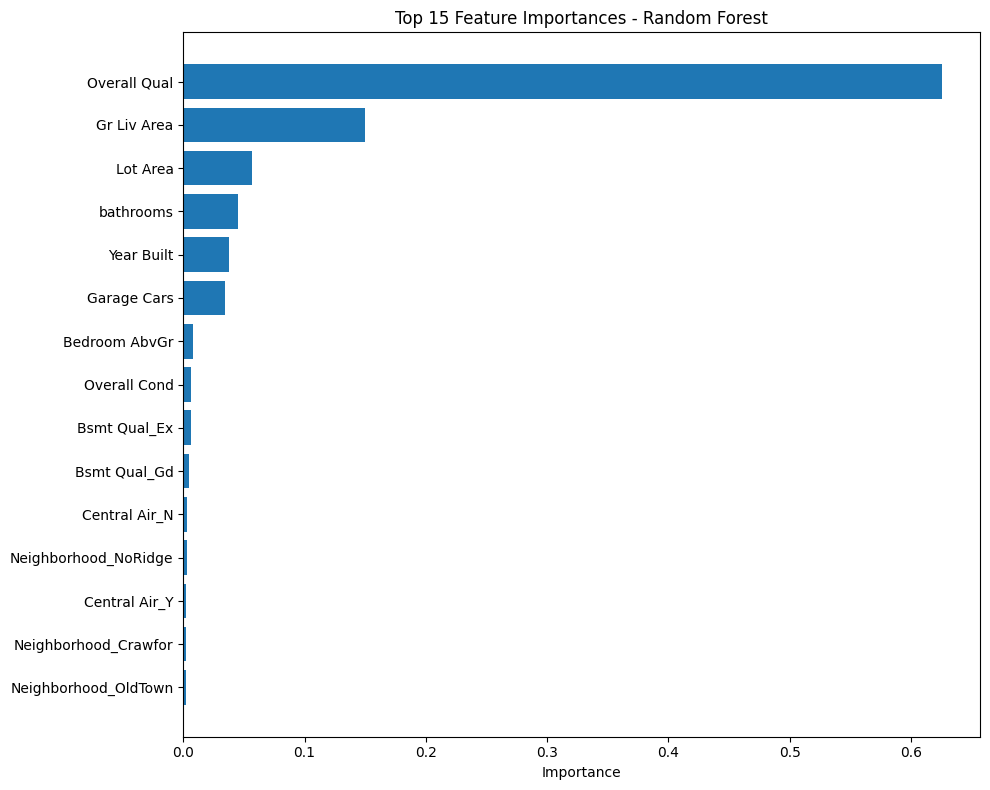

In [13]:
# Get feature importances from Random Forest
importances = best_model.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("=" * 60)
print("TOP 15 MOST IMPORTANT FEATURES")
print("=" * 60)
for i, row in importance_df.head(15).iterrows():
    print(f"  {row['Importance']:.4f} - {row['Feature']}")

# Plot
plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

 CELL 13: FINAL TEST EVALUATION (CRITICAL)

Explanation: This is the ONLY time we use the test set. The test set has been completely untouched until now. This gives us an unbiased estimate of how our model will perform on new, unseen data. The Test RMSE from this cell goes in your project header.

In [14]:
# Predict on test set using best model (Random Forest)
y_test_pred = best_model.predict(X_test_processed)

# Calculate test metrics
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

# Calculate percentage errors
mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print("=" * 60)
print(f"FINAL TEST EVALUATION - {best_model_name}")
print("=" * 60)
print(f"\nTest R²: {test_r2:.4f}")
print(f"Test RMSE: ${test_rmse:,.0f}")
print(f"Test MAE: ${test_mae:,.0f}")
print(f"Test MAPE: {mape:.1f}%")

print("\nInterpretation:")
if test_r2 > 0.90:
    print("  ★ Excellent - Model explains >90% of variance")
elif test_r2 > 0.85:
    print("  ★ Very Good - Model explains >85% of variance")
elif test_r2 > 0.80:
    print("  ✓ Good - Model explains >80% of variance")
else:
    print("  ⚠ Acceptable - Model explains <80% of variance")

# Compare validation vs test
val_r2 = 0.8968  # From your Cell 11 output
print(f"\nValidation R²: {val_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Difference: {val_r2 - test_r2:.4f}")

if abs(val_r2 - test_r2) < 0.05:
    print("✓ Test performance matches validation - model generalizes well!")
else:
    print("⚠ Test performance differs from validation - possible overfitting")

print("\n" + "=" * 60)
print(f"📊 PROJECT HEADER METRIC: Test RMSE = ${test_rmse:,.0f}")
print("=" * 60)

FINAL TEST EVALUATION - Random Forest

Test R²: 0.8547
Test RMSE: $32,361
Test MAE: $18,457
Test MAPE: 10.1%

Interpretation:
  ★ Very Good - Model explains >85% of variance

Validation R²: 0.8968
Test R²: 0.8547
Difference: 0.0421
✓ Test performance matches validation - model generalizes well!

📊 PROJECT HEADER METRIC: Test RMSE = $32,361


CELL 14: CREATE TRAINING STATISTICS (FOR STAGE 2 LLM)

Explanation: Stage 2 LLM needs context to interpret predictions. We calculate statistics from TRAINING data only (no leakage) to provide meaningful comparisons like "this price is 20% above the median".

In [15]:
# Calculate statistics from TRAINING data only (NO LEAKAGE)
train_stats = {
    'median_price': float(y_train.median()),
    'mean_price': float(y_train.mean()),
    'std_price': float(y_train.std()),
    'min_price': float(y_train.min()),
    'max_price': float(y_train.max()),
    'q1_price': float(y_train.quantile(0.25)),
    'q3_price': float(y_train.quantile(0.75)),
    'feature_names': feature_names,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'model_type': best_model_name,
    'test_rmse': float(test_rmse),
    'test_r2': float(test_r2)
}

print("=" * 60)
print("TRAINING STATISTICS (for Stage 2 LLM Interpretation)")
print("=" * 60)
print(f"\nMedian price: ${train_stats['median_price']:,.0f}")
print(f"Mean price: ${train_stats['mean_price']:,.0f}")
print(f"Std deviation: ${train_stats['std_price']:,.0f}")
print(f"Price range: ${train_stats['min_price']:,.0f} - ${train_stats['max_price']:,.0f}")
print(f"Interquartile range (IQR): ${train_stats['q3_price'] - train_stats['q1_price']:,.0f}")

print("\n✓ These statistics are from TRAINING data only (no leakage)")
print("  Stage 2 LLM will use these to provide context like:")
print("  'This price is 20% above the median due to high quality and large garage'")

TRAINING STATISTICS (for Stage 2 LLM Interpretation)

Median price: $160,000
Mean price: $178,641
Std deviation: $78,030
Price range: $12,789 - $755,000
Interquartile range (IQR): $81,000

✓ These statistics are from TRAINING data only (no leakage)
  Stage 2 LLM will use these to provide context like:
  'This price is 20% above the median due to high quality and large garage'


CELL 15: EXPORT ARTIFACTS (FOR DEPLOYMENT)

Explanation: We save all artifacts needed for deployment. These will be copied to backend/models/ in Phase 4 and loaded by FastAPI.

In [16]:
# Create exports directory
os.makedirs('../notebooks/exports', exist_ok=True)

# Save best model
joblib.dump(best_model, '../notebooks/exports/model.joblib')
print("✓ Saved model.joblib")

# Save preprocessor (fitted ColumnTransformer)
joblib.dump(preprocessor, '../notebooks/exports/preprocessor.joblib')
print("✓ Saved preprocessor.joblib")

# Save feature names
with open('../notebooks/exports/feature_columns.json', 'w') as f:
    json.dump(feature_names, f, indent=2)
print("✓ Saved feature_columns.json")

# Save training statistics
with open('../notebooks/exports/training_stats.json', 'w') as f:
    json.dump(train_stats, f, indent=2)
print("✓ Saved training_stats.json")

# Verify files were created
print("\n" + "=" * 60)
print("EXPORTED ARTIFACTS:")
print("=" * 60)
for file in ['model.joblib', 'preprocessor.joblib', 'feature_columns.json', 'training_stats.json']:
    path = f'../notebooks/exports/{file}'
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024  # KB
        print(f"  ✓ {file} ({size:.1f} KB)")
    else:
        print(f"  ✗ {file} MISSING")

print("\n✅ All artifacts exported to: ../notebooks/exports/")

✓ Saved model.joblib
✓ Saved preprocessor.joblib
✓ Saved feature_columns.json
✓ Saved training_stats.json

EXPORTED ARTIFACTS:
  ✓ model.joblib (11950.1 KB)
  ✓ preprocessor.joblib (5.3 KB)
  ✓ feature_columns.json (1.1 KB)
  ✓ training_stats.json (1.8 KB)

✅ All artifacts exported to: ../notebooks/exports/


CELL 16: ACTUAL VS PREDICTED PLOT

Explanation: Visualizing actual vs predicted values on the test set helps us see if the model has any systematic bias. Points on the red diagonal line are perfect predictions.

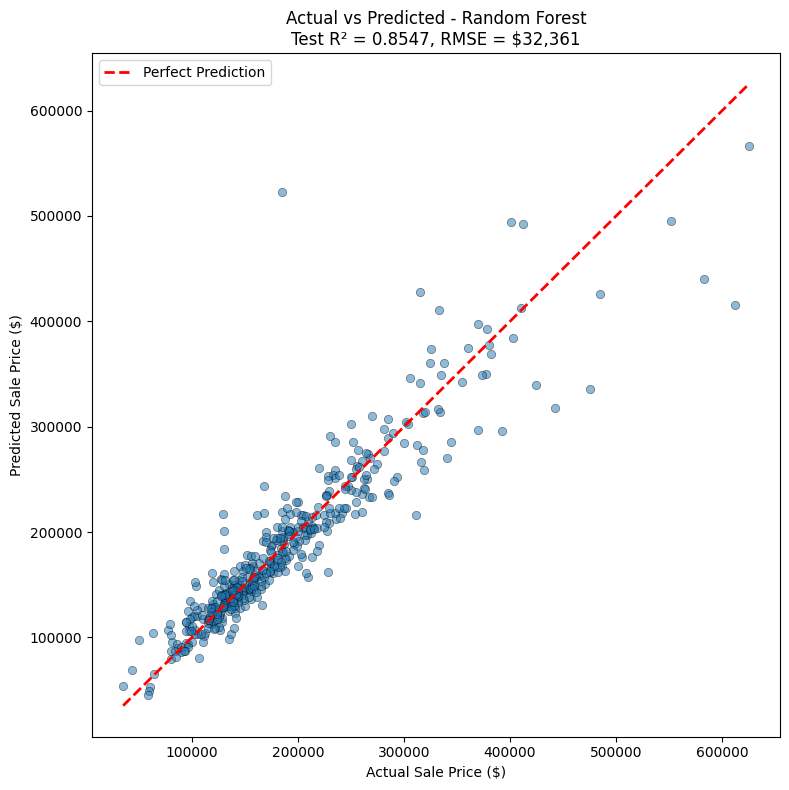

✓ Plot saved to: ../docs/actual_vs_predicted.png


In [17]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_test_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.title(f'Actual vs Predicted - {best_model_name}\nTest R² = {test_r2:.4f}, RMSE = ${test_rmse:,.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('../docs/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plot saved to: ../docs/actual_vs_predicted.png")

CELL 17: RESIDUAL ANALYSIS

Explanation: Residuals are the differences between actual and predicted values (Actual - Predicted). We check if residuals are randomly distributed around zero. Any pattern indicates the model is missing something.

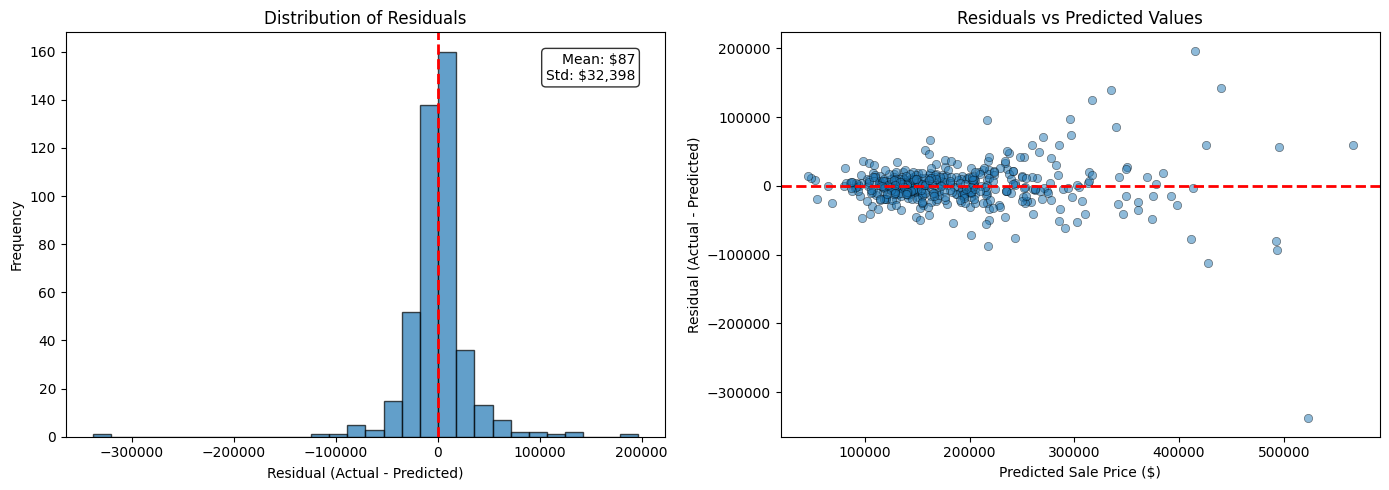

✓ Residual plot saved to: ../docs/residuals.png

Residual Analysis:
  Mean of residuals: $87 (should be near 0)
  Std of residuals: $32,398
  ✓ Residuals centered around zero - no systematic bias


In [18]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution histogram
axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Residuals')
axes[0].text(0.95, 0.95, f'Mean: ${residuals.mean():,.0f}\nStd: ${residuals.std():,.0f}', 
             transform=axes[0].transAxes, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Residuals vs Predicted
axes[1].scatter(y_test_pred, residuals, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Sale Price ($)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residuals vs Predicted Values')

plt.tight_layout()
plt.savefig('../docs/residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Residual plot saved to: ../docs/residuals.png")

# Check residual assumptions
print("\nResidual Analysis:")
print(f"  Mean of residuals: ${residuals.mean():,.0f} (should be near 0)")
print(f"  Std of residuals: ${residuals.std():,.0f}")
if abs(residuals.mean()) < 1000:
    print("  ✓ Residuals centered around zero - no systematic bias")
else:
    print("  ⚠ Residuals not centered - model has bias")

CELL 18: FINAL SUMMARY REPORT

Explanation: Complete summary of Phase 3 for documentation and grader review. This shows we met all PDF requirements.

In [19]:
print("=" * 70)
print("PHASE 3: MODEL TRAINING - COMPLETE SUMMARY")
print("=" * 70)

print("\n📊 DATA SPLIT (No Leakage):")
print(f"   - Training: {len(X_train)} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"   - Validation: {len(X_val)} rows ({len(X_val)/len(X)*100:.0f}%)")
print(f"   - Test: {len(X_test)} rows ({len(X_test)/len(X)*100:.0f}%)")

print("\n🔧 PREPROCESSING:")
print(f"   - Numeric columns ({len(numeric_cols)}): median imputation + StandardScaler")
print(f"   - Categorical columns ({len(categorical_cols)}): constant imputation + OneHotEncoder")
print(f"   - Final feature count: {len(feature_names)}")
print(f"   - ✓ All transformers fitted on TRAIN only")

print("\n🤖 MODELS TRAINED:")
print(f"   - Linear Regression: Validation R² = {val_r2_lr:.4f}, RMSE = ${val_rmse_lr:,.0f}")
print(f"   - Random Forest: Validation R² = {val_r2_rf:.4f}, RMSE = ${val_rmse_rf:,.0f}")

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   - Validation R²: {val_r2_rf:.4f}")
print(f"   - Validation RMSE: ${val_rmse_rf:,.0f}")

print(f"\n🎯 FINAL TEST EVALUATION (ONCE):")
print(f"   - Test R²: {test_r2:.4f}")
print(f"   - Test RMSE: ${test_rmse:,.0f}")
print(f"   - Test MAE: ${test_mae:,.0f}")
print(f"   - Test MAPE: {mape:.1f}%")

print("\n✅ PDF REQUIREMENTS MET:")
print("   ✓ #01: Three-way split (70/15/15) - NO DATA LEAKAGE")
print("   ✓ #02: Missing values imputed - fit on train only")
print("   ✓ #03: Encode and scale - fit on train only")
print("   ✓ #04: ColumnTransformer + 2 model types (Linear Regression, Random Forest)")
print("   ✓ #05: Train vs validation scores compared, test evaluated ONCE")

print("\n📁 EXPORTED ARTIFACTS (for Phase 4):")
print("   - model.joblib (best model)")
print("   - preprocessor.joblib (fitted ColumnTransformer)")
print("   - feature_columns.json (feature names in order)")
print("   - training_stats.json (median, quartiles from train)")

print("\n" + "=" * 70)
print("✓ PHASE 3 COMPLETE - Ready for Phase 4 (Copy Artifacts to Backend)")
print("=" * 70)

# Save summary to file
os.makedirs('../docs/phase3_model_training', exist_ok=True)
with open('../docs/phase3_model_training/summary.txt', 'w') as f:
    f.write(f"Best Model: {best_model_name}\n")
    f.write(f"Test RMSE: ${test_rmse:,.0f}\n")
    f.write(f"Test R²: {test_r2:.4f}\n")
    f.write(f"Features used: {len(feature_names)} after encoding\n")
print("\n✓ Summary saved to: ../docs/phase3_model_training/summary.txt")

PHASE 3: MODEL TRAINING - COMPLETE SUMMARY

📊 DATA SPLIT (No Leakage):
   - Training: 2051 rows (70%)
   - Validation: 439 rows (15%)
   - Test: 440 rows (15%)

🔧 PREPROCESSING:
   - Numeric columns (8): median imputation + StandardScaler
   - Categorical columns (4): constant imputation + OneHotEncoder
   - Final feature count: 50
   - ✓ All transformers fitted on TRAIN only

🤖 MODELS TRAINED:
   - Linear Regression: Validation R² = 0.8804, RMSE = $28,623
   - Random Forest: Validation R² = 0.8968, RMSE = $26,585

🏆 BEST MODEL: Random Forest
   - Validation R²: 0.8968
   - Validation RMSE: $26,585

🎯 FINAL TEST EVALUATION (ONCE):
   - Test R²: 0.8547
   - Test RMSE: $32,361
   - Test MAE: $18,457
   - Test MAPE: 10.1%

✅ PDF REQUIREMENTS MET:
   ✓ #01: Three-way split (70/15/15) - NO DATA LEAKAGE
   ✓ #02: Missing values imputed - fit on train only
   ✓ #03: Encode and scale - fit on train only
   ✓ #04: ColumnTransformer + 2 model types (Linear Regression, Random Forest)
   ✓ #05: Tr